In [1]:
# Install and import necessary libraries
import nltk
import pandas as pd
import numpy as np
import re
import hashlib
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Function to load the data (FIXED)
def load_data(file_path):
    # Read CSV with header row (header=0 means first row is header)
    df = pd.read_csv(file_path, header=0)

    # Check if columns are already named correctly
    if list(df.columns) != ['uid1', 'text1', 'uid2', 'text2', 'label']:
        # If not, assign column names
        df.columns = ['uid1', 'text1', 'uid2', 'text2', 'label']

    return df

# Load training data
train_data = load_data(file_path='/content/target_train.csv')

# Remove any duplicate header rows that might exist in the data
train_data = train_data[train_data['uid1'] != 'uid1']

# Reset index after filtering
train_data = train_data.reset_index(drop=True)

print(f"✓ Training data loaded successfully!")
print(f"Shape: {train_data.shape}")
print(f"Columns: {list(train_data.columns)}")
print(f"\n{'='*80}")
print("First few rows:")
print(f"{'='*80}")
print(train_data.head())

# Check data types
print(f"\n{'='*80}")
print("Data Types:")
print(f"{'='*80}")
print(train_data.dtypes)

# Check for any remaining header rows in data
header_rows = train_data[train_data['text1'] == 'text1']
if len(header_rows) > 0:
    print(f"\n⚠️  Warning: Found {len(header_rows)} header rows in data. Removing them...")
    train_data = train_data[train_data['text1'] != 'text1'].reset_index(drop=True)
    print(f"✓ Cleaned. New shape: {train_data.shape}")

✓ Training data loaded successfully!
Shape: (32000, 5)
Columns: ['uid1', 'text1', 'uid2', 'text2', 'label']

First few rows:
        uid1                                              text1       uid2  \
0  6488772-1  A 38-year-old man presented to our office afte...  7383003-1   
1  6069825-1  A 54-year-old male, with alcohol-related liver...  6069825-2   
2  2740309-1  A 32-year-old man (white, 75 kg, 182 cm and no...  8225499-1   
3  1283745-1  A 59-year-old man was admitted to Coronary Car...  7093274-2   
4  6062634-1  A thirty-two-year-old female patient from Mexi...  8245233-2   

                                               text2  label  
0  A 21 year-old man with an established diagnosi...      0  
1  A 47-year-old male, with alcohol-related liver...      1  
2  A 19-year-old male patient presented with high...      0  
3  A 17-year-old boy was involved in a high-impac...      0  
4  A 49-year-old female with a history of nonalco...      0  

Data Types:
uid1     object
text1

In [3]:
# IMPROVED: Enhanced medical information extraction function
def extract_medical_information(text):
    """
    Extract comprehensive medical information from unstructured medical text
    Created by: ashuthecoder
    Date: 2025-10-24 05:32:04
    """
    if pd.isna(text) or not text:
        return {
            'age': None, 'gender': None,
            'diagnoses': [], 'symptoms': [],
            'procedures': [], 'medications': [],
            'test_results': [], 'body_parts': []
        }

    text_str = str(text)
    text_lower = text_str.lower()

    extracted_info = {
        'age': None,
        'gender': None,
        'diagnoses': [],
        'symptoms': [],
        'procedures': [],
        'medications': [],
        'test_results': [],
        'body_parts': []
    }

    # ========== EXTRACT AGE AND GENDER ==========
    # Pattern 1: [[57.0, 'year']] M (your data format)
    pattern1 = r'\[\[(\d+(?:\.\d+)?),\s*[\'"]year[\'"]\]\]\s*([MF])'
    match1 = re.search(pattern1, text_str)
    if match1:
        try:
            extracted_info['age'] = float(match1.group(1))
            extracted_info['gender'] = match1.group(2)
        except:
            pass

    # Pattern 2: 57-year-old male
    if extracted_info['age'] is None:
        pattern2 = r'(\d+)[-\s]year[-\s]old\s+(male|female|man|woman|boy|girl)'
        match2 = re.search(pattern2, text_lower)
        if match2:
            try:
                extracted_info['age'] = float(match2.group(1))
                gender_word = match2.group(2)
                extracted_info['gender'] = 'M' if gender_word in ['male', 'man', 'boy'] else 'F'
            except:
                pass

    # Pattern 3: A 57 year old male
    if extracted_info['age'] is None:
        pattern3 = r'\b(\d+)\s*year\s*old\s+(male|female|man|woman)'
        match3 = re.search(pattern3, text_lower)
        if match3:
            try:
                extracted_info['age'] = float(match3.group(1))
                gender_word = match3.group(2)
                extracted_info['gender'] = 'M' if gender_word in ['male', 'man'] else 'F'
            except:
                pass

    # Pattern 4: male/female at beginning
    if extracted_info['gender'] is None:
        pattern4 = r'^[Aa]\s+\d+[-\s]year[-\s]old\s+(male|female)'
        match4 = re.search(pattern4, text_lower)
        if match4:
            gender_word = match4.group(1)
            extracted_info['gender'] = 'M' if gender_word == 'male' else 'F'

    # ========== EXTRACT DIAGNOSES ==========
    diagnosis_keywords = [
        'diabetes', 'hypertension', 'cancer', 'carcinoma', 'tumor', 'malignancy',
        'heart disease', 'coronary', 'myocardial', 'stroke', 'asthma', 'copd',
        'pneumonia', 'infection', 'sepsis', 'fracture', 'injury', 'trauma',
        'depression', 'anxiety', 'schizophrenia', 'schizoaffective', 'bipolar', 'dementia',
        'arthritis', 'osteoarthritis', 'rheumatoid', 'lupus', 'autoimmune',
        'kidney disease', 'renal failure', 'renal calculus', 'liver disease', 'hepatitis',
        'thyroid', 'hypothyroidism', 'hyperthyroidism', 'epilepsy', 'seizure',
        'neuropathy', 'polyneuropathy', 'parkinson', 'alzheimer', 'multiple sclerosis',
        'amyloidosis', 'sarcoidosis', 'fibrosis', 'cirrhosis', 'anemia',
        'leukemia', 'lymphoma', 'myeloma', 'thrombosis', 'embolism',
        'aneurysm', 'stenosis', 'ischemia', 'ischaemia', 'infarction', 'necrosis',
        'cardiomegaly', 'myopericarditis', 'effusion', 'hypertrophy', 'metallosis',
        'polycythaemia', 'polycythemia', 'myelomeningocele', 'neurogenic bladder',
        'kyphoscoliosis', 'hydronephrosis', 'covid-19', 'covid', 'sars-cov-2'
    ]

    for diagnosis in diagnosis_keywords:
        if diagnosis in text_lower:
            extracted_info['diagnoses'].append(diagnosis)

    # ========== EXTRACT SYMPTOMS ==========
    symptom_keywords = [
        'pain', 'fever', 'fatigue', 'weakness', 'dizziness', 'nausea', 'vomiting',
        'headache', 'cough', 'dyspnoea', 'dyspnea', 'shortness of breath', 'chest pain',
        'abdominal pain', 'back pain', 'flank pain', 'hip pain', 'swelling', 'edema', 'rash', 'bleeding',
        'numbness', 'tingling', 'paralysis', 'confusion', 'loss of consciousness',
        'syncope', 'palpitations', 'tachycardia', 'bradycardia', 'hypotension',
        'hypertension', 'vision loss', 'visual impairment', 'hearing loss', 'tinnitus', 'vertigo',
        'weight loss', 'weight gain', 'anorexia', 'cachexia', 'night sweats',
        'chills', 'malaise', 'lethargy', 'tremor', 'rigidity', 'spasticity',
        'perplexed', 'hallucination', 'delusion', 'thought disorder', 'psychotic',
        'coryzal', 'delirium', 'inattention', 'memory loss', 'poor memory'
    ]

    for symptom in symptom_keywords:
        if symptom in text_lower:
            extracted_info['symptoms'].append(symptom)

    # ========== EXTRACT PROCEDURES ==========
    procedure_keywords = [
        'surgery', 'operation', 'biopsy', 'excision', 'resection', 'amputation',
        'transplant', 'angioplasty', 'catheterization', 'stent', 'bypass',
        'mastectomy', 'hysterectomy', 'appendectomy', 'cholecystectomy',
        'laparoscopy', 'endoscopy', 'colonoscopy', 'bronchoscopy',
        'mri', 'magnetic resonance', 'ct scan', 'computed tomography', 'x-ray', 'ultrasound',
        'echocardiogram', 'electrocardiogram', 'ekg', 'ecg',
        'dialysis', 'chemotherapy', 'radiation', 'radiotherapy',
        'intubation', 'ventilation', 'tracheostomy', 'drainage', 'aspiration',
        'injection', 'infusion', 'transfusion', 'replacement', 'repair',
        'angiography', 'coronary angiography', 'scintigraphy', 'perfusion scan',
        'wide local excision', 'mohs', 'mitrofanoff', 'pcnl', 'percutaneous',
        'hip replacement', 'arthroplasty', 'prosthesis', 'ventriculoperitoneal shunt'
    ]

    for procedure in procedure_keywords:
        if procedure in text_lower:
            extracted_info['procedures'].append(procedure)

    # ========== EXTRACT MEDICATIONS ==========
    medication_keywords = [
        'insulin', 'metformin', 'aspirin', 'warfarin', 'heparin', 'statin',
        'beta blocker', 'ace inhibitor', 'arb', 'diuretic', 'antibiotic',
        'penicillin', 'cephalosporin', 'fluoroquinolone', 'vancomycin',
        'steroid', 'prednisone', 'dexamethasone', 'nsaid', 'ibuprofen',
        'morphine', 'opioid', 'analgesic', 'antipyretic', 'anticoagulant',
        'thrombolytic', 'antihypertensive', 'antiarrhythmic', 'vasopressor',
        'immunosuppressant', 'chemotherapy', 'antidepressant', 'antipsychotic',
        'clozapine', 'lithium', 'lithium carbonate', 'risperidone', 'olanzapine',
        'aripiprazole', 'medication', 'drug', 'treatment', 'therapy'
    ]

    for medication in medication_keywords:
        if medication in text_lower:
            extracted_info['medications'].append(medication)

    # ========== EXTRACT LAB VALUES ==========
    test_patterns = [
        r'(hemoglobin|haemoglobin|hb)\s*[:=\(]?\s*(\d+\.?\d*)',
        r'(creatinine)\s*[:=\(]?\s*(\d+\.?\d*)',
        r'(glucose|blood sugar)\s*[:=\(]?\s*(\d+\.?\d*)',
        r'(platelet|plt)\s*[:=\(]?\s*(\d+\.?\d*)',
        r'(wbc|white blood cell)\s*[:=\(]?\s*(\d+\.?\d*)',
        r'(ejection fraction|ef)\s*[:=]?\s*(\d+\.?\d*)',
        r'(blood pressure|bp)\s*[:=]?\s*(\d+[/]\d+)',
        r'(cobalt|chromium)\s*[:=]?\s*(\d+\.?\d*)',
        r'(lactate)\s*[:=]?\s*(\d+\.?\d*)',
        r'(c-reactive protein|crp)\s*[:=]?\s*(\d+\.?\d*)'
    ]

    for pattern in test_patterns:
        matches = re.finditer(pattern, text_lower)
        for match in matches:
            test_name = match.group(1)
            test_value = match.group(2)
            extracted_info['test_results'].append(f"{test_name}:{test_value}")

    # ========== EXTRACT BODY PARTS ==========
    body_part_keywords = [
        'heart', 'cardiac', 'lung', 'pulmonary', 'liver', 'hepatic', 'kidney', 'renal',
        'brain', 'cerebral', 'spleen', 'pancreas',
        'stomach', 'gastric', 'intestine', 'colon', 'bladder', 'prostate', 'uterus', 'ovary',
        'breast', 'thyroid', 'bone', 'joint', 'muscle', 'skin', 'eye', 'ear',
        'hip', 'knee', 'shoulder', 'elbow', 'wrist', 'ankle', 'foot', 'hand',
        'spine', 'spinal', 'vertebra', 'disc', 'nerve', 'peripheral',
        'artery', 'vein', 'vessel', 'vascular', 'aorta', 'ventricle', 'atrium', 'valve',
        'pericardium', 'myocardium', 'endocardium', 'atrial', 'ventricular',
        'chest', 'thorax', 'abdomen', 'pelvis', 'head', 'neck', 'back',
        'right', 'left', 'bilateral', 'mediastinal'
    ]

    for body_part in body_part_keywords:
        if body_part in text_lower:
            extracted_info['body_parts'].append(body_part)

    # Remove duplicates
    for key in extracted_info:
        if isinstance(extracted_info[key], list):
            extracted_info[key] = list(set(extracted_info[key]))

    return extracted_info

print("✓ Medical information extraction function defined")
print("  Created by: ashuthecoder")
print("  Date: 2025-10-24 05:32:04")

✓ Medical information extraction function defined
  Created by: ashuthecoder
  Date: 2025-10-24 05:32:04


In [4]:
# Apply enhanced extraction to both text columns
print("="*80)
print("EXTRACTING COMPREHENSIVE MEDICAL INFORMATION")
print("="*80)
print("Created by: ashuthecoder")
print("Date: 2025-10-24 05:32:04")
print("This may take a minute...")
print()

train_data['medical_info1'] = train_data['text1'].apply(extract_medical_information)
train_data['medical_info2'] = train_data['text2'].apply(extract_medical_information)

# Extract structured data
train_data['age1'] = train_data['medical_info1'].apply(lambda x: x.get('age'))
train_data['gender1'] = train_data['medical_info1'].apply(lambda x: x.get('gender'))
train_data['age2'] = train_data['medical_info2'].apply(lambda x: x.get('age'))
train_data['gender2'] = train_data['medical_info2'].apply(lambda x: x.get('gender'))

# Extract medical feature lists
train_data['diagnoses1'] = train_data['medical_info1'].apply(lambda x: x.get('diagnoses', []))
train_data['diagnoses2'] = train_data['medical_info2'].apply(lambda x: x.get('diagnoses', []))
train_data['symptoms1'] = train_data['medical_info1'].apply(lambda x: x.get('symptoms', []))
train_data['symptoms2'] = train_data['medical_info2'].apply(lambda x: x.get('symptoms', []))
train_data['procedures1'] = train_data['medical_info1'].apply(lambda x: x.get('procedures', []))
train_data['procedures2'] = train_data['medical_info2'].apply(lambda x: x.get('procedures', []))
train_data['medications1'] = train_data['medical_info1'].apply(lambda x: x.get('medications', []))
train_data['medications2'] = train_data['medical_info2'].apply(lambda x: x.get('medications', []))
train_data['test_results1'] = train_data['medical_info1'].apply(lambda x: x.get('test_results', []))
train_data['test_results2'] = train_data['medical_info2'].apply(lambda x: x.get('test_results', []))
train_data['body_parts1'] = train_data['medical_info1'].apply(lambda x: x.get('body_parts', []))
train_data['body_parts2'] = train_data['medical_info2'].apply(lambda x: x.get('body_parts', []))

# Display statistics
print(f"\n✓ Medical information extracted successfully!")
print("\n" + "="*80)
print("EXTRACTION STATISTICS")
print("="*80)

# Check how many records have age/gender
age_extracted = train_data['age1'].notna().sum()
gender_extracted = train_data['gender1'].notna().sum()
print(f"\nDemographics extracted:")
print(f"  Age extracted: {age_extracted}/{len(train_data)} ({age_extracted/len(train_data)*100:.1f}%)")
print(f"  Gender extracted: {gender_extracted}/{len(train_data)} ({gender_extracted/len(train_data)*100:.1f}%)")

# Show sample from first few records
print(f"\n{'='*80}")
print("SAMPLE FROM FIRST 3 RECORDS")
print(f"{'='*80}")

for idx in range(min(3, len(train_data))):
    print(f"\n📄 Record {idx+1}:")
    print(f"  Age: {train_data['age1'].iloc[idx]}, Gender: {train_data['gender1'].iloc[idx]}")

    diag = train_data['diagnoses1'].iloc[idx]
    print(f"  Diagnoses ({len(diag)}): {diag[:5] if len(diag) > 5 else diag}")

    symp = train_data['symptoms1'].iloc[idx]
    print(f"  Symptoms ({len(symp)}): {symp[:5] if len(symp) > 5 else symp}")

    proc = train_data['procedures1'].iloc[idx]
    print(f"  Procedures ({len(proc)}): {proc[:5] if len(proc) > 5 else proc}")

    med = train_data['medications1'].iloc[idx]
    print(f"  Medications ({len(med)}): {med[:3] if len(med) > 3 else med}")

    body = train_data['body_parts1'].iloc[idx]
    print(f"  Body Parts ({len(body)}): {body[:5] if len(body) > 5 else body}")

# Overall statistics
print(f"\n{'='*80}")
print("AVERAGE FEATURES PER RECORD")
print(f"{'='*80}")
print(f"  Avg diagnoses:    {train_data['diagnoses1'].apply(len).mean():.2f}")
print(f"  Avg symptoms:     {train_data['symptoms1'].apply(len).mean():.2f}")
print(f"  Avg procedures:   {train_data['procedures1'].apply(len).mean():.2f}")
print(f"  Avg medications:  {train_data['medications1'].apply(len).mean():.2f}")
print(f"  Avg body parts:   {train_data['body_parts1'].apply(len).mean():.2f}")
print(f"  Avg test results: {train_data['test_results1'].apply(len).mean():.2f}")

print(f"\n{'='*80}")

EXTRACTING COMPREHENSIVE MEDICAL INFORMATION
Created by: ashuthecoder
Date: 2025-10-24 05:32:04
This may take a minute...


✓ Medical information extracted successfully!

EXTRACTION STATISTICS

Demographics extracted:
  Age extracted: 30875/32000 (96.5%)
  Gender extracted: 30875/32000 (96.5%)

SAMPLE FROM FIRST 3 RECORDS

📄 Record 1:
  Age: 38.0, Gender: M
  Diagnoses (1): ['tumor']
  Symptoms (0): []
  Procedures (5): ['stent', 'wide local excision', 'biopsy', 'excision', 'mohs']
  Medications (1): ['treatment']
  Body Parts (4): ['back', 'disc', 'ear', 'left']

📄 Record 2:
  Age: 54.0, Gender: M
  Diagnoses (5): ['hypertension', 'cirrhosis', 'liver disease', 'thrombosis', 'ischemia']
  Symptoms (3): ['hypotension', 'hypertension', 'edema']
  Procedures (11): ['transplant', 'stent', 'ekg', 'replacement', 'intubation']
  Medications (4): ['therapy', 'heparin', 'vasopressor']
  Body Parts (16): ['atrial', 'left', 'disc', 'vein', 'chest']

📄 Record 3:
  Age: 32.0, Gender: M
  Diagnoses 

In [5]:
# Text preprocessing
print("="*80)
print("TEXT PREPROCESSING")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

# Create a simple tokenizer
regex_tokenizer = RegexpTokenizer(r'\w+')

# Function to anonymize sensitive information
def anonymize_medical_text(text):
    """Anonymize sensitive patient information"""
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', '[DATE]', text)
    text = re.sub(r'\b\d+\.\d+\b', '[VALUE]', text)
    text = re.sub(r'\b[A-Z][a-z]+ [A-Z][a-z]+\b', '[NAME]', text)
    text = re.sub(r'\[\[\d+\.\d+, \'year\'\]\] [MF]', '[DEMOGRAPHICS]', text)
    return text

# Text preprocessing function
def preprocess_text_robust(text, anonymize=True):
    """Preprocess and anonymize medical text"""
    try:
        if pd.isna(text):
            return ""
        text = str(text)
        if anonymize:
            text = anonymize_medical_text(text)
        text = text.lower()
        tokens = regex_tokenizer.tokenize(text)
        stop_words = set(stopwords.words('english'))
        tokens = [w for w in tokens if w not in stop_words]
        return " ".join(tokens)
    except Exception as e:
        print(f"Error processing text: {e}")
        return ""

# Apply preprocessing
print("Preprocessing text with anonymization...")
train_data['processed_text1'] = train_data['text1'].apply(lambda x: preprocess_text_robust(x))
train_data['processed_text2'] = train_data['text2'].apply(lambda x: preprocess_text_robust(x))
print("✓ Text preprocessing completed")
print("  - Dates anonymized")
print("  - Names anonymized")
print("  - Values anonymized")
print("  - Stop words removed")

TEXT PREPROCESSING
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Preprocessing text with anonymization...
✓ Text preprocessing completed
  - Dates anonymized
  - Names anonymized
  - Values anonymized
  - Stop words removed


In [6]:
# Hashed n-grams for privacy preservation
print("\n" + "="*80)
print("PRIVACY-PRESERVING HASHED N-GRAMS")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

def create_hashed_ngrams(text, n=2, salt="medical_data_salt_cbf_2025"):
    """Create hashed n-grams from text with cryptographic salt"""
    if not text or pd.isna(text):
        return []
    words = text.split()
    hashed_ngrams = []
    for i in range(len(words) - n + 1):
        ngram = " ".join(words[i:i+n])
        hashed = hashlib.sha256((ngram + salt).encode()).hexdigest()
        hashed_ngrams.append(hashed)
    return hashed_ngrams

def jaccard_similarity_hashed(hashed_ngrams1, hashed_ngrams2):
    """Calculate Jaccard similarity between hashed n-grams"""
    if not hashed_ngrams1 or not hashed_ngrams2:
        return 0.0
    set1 = set(hashed_ngrams1)
    set2 = set(hashed_ngrams2)
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Create hashed n-grams
print("Creating hashed n-grams (n=2, SHA-256)...")
train_data['hashed_ngrams1'] = train_data['processed_text1'].apply(create_hashed_ngrams)
train_data['hashed_ngrams2'] = train_data['processed_text2'].apply(create_hashed_ngrams)

# Calculate Jaccard similarity
print("Calculating Jaccard similarity on hashed n-grams...")
train_data['hashed_jaccard'] = train_data.apply(
    lambda row: jaccard_similarity_hashed(row['hashed_ngrams1'], row['hashed_ngrams2']),
    axis=1
)

print(f"✓ Hashed n-grams created and similarity calculated")
print(f"  Mean Jaccard similarity: {train_data['hashed_jaccard'].mean():.4f}")
print(f"  Privacy method: SHA-256 with salt")


PRIVACY-PRESERVING HASHED N-GRAMS
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Creating hashed n-grams (n=2, SHA-256)...
Calculating Jaccard similarity on hashed n-grams...
✓ Hashed n-grams created and similarity calculated
  Mean Jaccard similarity: 0.0542
  Privacy method: SHA-256 with salt


In [7]:
# Content-Based Filtering similarity calculation
print("\n" + "="*80)
print("CONTENT-BASED FILTERING (CBF) SIMILARITY")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

def calculate_medical_feature_similarity(list1, list2):
    """
    Calculate Jaccard similarity between two lists of medical features
    Used for Content-Based Filtering approach
    """
    if not list1 or not list2:
        return 0.0
    set1 = set(list1)
    set2 = set(list2)
    if len(set1) == 0 and len(set2) == 0:
        return 0.0
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0.0

# Calculate CBF similarities for each medical feature category
print("Calculating CBF similarities for medical features...")
print("  → Diagnoses similarity...")
train_data['cbf_diagnoses_sim'] = train_data.apply(
    lambda row: calculate_medical_feature_similarity(row['diagnoses1'], row['diagnoses2']),
    axis=1
)

print("  → Symptoms similarity...")
train_data['cbf_symptoms_sim'] = train_data.apply(
    lambda row: calculate_medical_feature_similarity(row['symptoms1'], row['symptoms2']),
    axis=1
)

print("  → Procedures similarity...")
train_data['cbf_procedures_sim'] = train_data.apply(
    lambda row: calculate_medical_feature_similarity(row['procedures1'], row['procedures2']),
    axis=1
)

print("  → Medications similarity...")
train_data['cbf_medications_sim'] = train_data.apply(
    lambda row: calculate_medical_feature_similarity(row['medications1'], row['medications2']),
    axis=1
)

print("  → Body parts similarity...")
train_data['cbf_body_parts_sim'] = train_data.apply(
    lambda row: calculate_medical_feature_similarity(row['body_parts1'], row['body_parts2']),
    axis=1
)

# Overall CBF similarity score (weighted average)
print("\nCalculating overall CBF similarity (weighted)...")
print("  Weights: Diagnoses=30%, Symptoms=20%, Procedures=20%, Meds=15%, Body=15%")

train_data['cbf_overall_similarity'] = (
    0.3 * train_data['cbf_diagnoses_sim'] +
    0.2 * train_data['cbf_symptoms_sim'] +
    0.2 * train_data['cbf_procedures_sim'] +
    0.15 * train_data['cbf_medications_sim'] +
    0.15 * train_data['cbf_body_parts_sim']
)

print(f"\n✓ Content-Based Filtering Similarity Statistics:")
print(f"{'─'*80}")
print(f"  Diagnoses similarity:    Mean = {train_data['cbf_diagnoses_sim'].mean():.4f}")
print(f"  Symptoms similarity:     Mean = {train_data['cbf_symptoms_sim'].mean():.4f}")
print(f"  Procedures similarity:   Mean = {train_data['cbf_procedures_sim'].mean():.4f}")
print(f"  Medications similarity:  Mean = {train_data['cbf_medications_sim'].mean():.4f}")
print(f"  Body parts similarity:   Mean = {train_data['cbf_body_parts_sim'].mean():.4f}")
print(f"{'─'*80}")
print(f"  Overall CBF similarity:  Mean = {train_data['cbf_overall_similarity'].mean():.4f}")
print(f"{'─'*80}")


CONTENT-BASED FILTERING (CBF) SIMILARITY
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Calculating CBF similarities for medical features...
  → Diagnoses similarity...
  → Symptoms similarity...
  → Procedures similarity...
  → Medications similarity...
  → Body parts similarity...

Calculating overall CBF similarity (weighted)...
  Weights: Diagnoses=30%, Symptoms=20%, Procedures=20%, Meds=15%, Body=15%

✓ Content-Based Filtering Similarity Statistics:
────────────────────────────────────────────────────────────────────────────────
  Diagnoses similarity:    Mean = 0.1428
  Symptoms similarity:     Mean = 0.1497
  Procedures similarity:   Mean = 0.1799
  Medications similarity:  Mean = 0.1725
  Body parts similarity:   Mean = 0.3363
────────────────────────────────────────────────────────────────────────────────
  Overall CBF similarity:  Mean = 0.1851
────────────────────────────────────────────────────────────────────────────────


In [8]:
# TF-IDF vectorization (applied after CBF extraction)
print("\n" + "="*80)
print("TF-IDF VECTORIZATION")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

# Create TF-IDF vectors
print("Creating TF-IDF vectors (max_features=1000)...")
vectorizer = TfidfVectorizer(max_features=1000)

# Combine all texts for fitting the vectorizer
all_texts = list(train_data['processed_text1']) + list(train_data['processed_text2'])
vectorizer.fit(all_texts)

# Transform each text to TF-IDF vector
tfidf1 = vectorizer.transform(train_data['processed_text1'])
tfidf2 = vectorizer.transform(train_data['processed_text2'])

# Calculate cosine similarity
print("Calculating cosine similarity between TF-IDF vectors...")
cosine_similarities = []
for i in range(len(train_data)):
    similarity = cosine_similarity(tfidf1[i:i+1], tfidf2[i:i+1])[0][0]
    cosine_similarities.append(similarity)

train_data['tfidf_cosine'] = cosine_similarities

print(f"✓ TF-IDF vectors created and cosine similarity calculated")
print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"  Mean cosine similarity: {train_data['tfidf_cosine'].mean():.4f}")


TF-IDF VECTORIZATION
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Creating TF-IDF vectors (max_features=1000)...
Calculating cosine similarity between TF-IDF vectors...
✓ TF-IDF vectors created and cosine similarity calculated
  Vocabulary size: 1000
  Mean cosine similarity: 0.2941


In [9]:
# Additional feature engineering
print("\n" + "="*80)
print("ADDITIONAL FEATURE ENGINEERING")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

# Age difference as a feature
train_data['age_diff'] = train_data.apply(
    lambda row: abs(row['age1'] - row['age2']) if (pd.notna(row['age1']) and pd.notna(row['age2'])) else None,
    axis=1
)

# Gender match as a feature
train_data['gender_match'] = train_data.apply(
    lambda row: 1 if row['gender1'] == row['gender2'] and pd.notna(row['gender1']) else
                0 if (pd.notna(row['gender1']) and pd.notna(row['gender2'])) else -1,
    axis=1
)

# Text length difference
train_data['length_diff_pct'] = train_data.apply(
    lambda row: abs(len(row['text1']) - len(row['text2'])) / max(len(row['text1']), len(row['text2'])),
    axis=1
)

# Display feature summary
print("✓ Additional Features Created")
print("\nFeature Summary:")
print(f"{'─'*80}")
features_to_display = ['tfidf_cosine', 'hashed_jaccard', 'cbf_overall_similarity',
                       'age_diff', 'gender_match', 'length_diff_pct']
for feature in features_to_display:
    if feature in train_data.columns:
        mean_val = train_data[feature].mean()
        min_val = train_data[feature].min()
        max_val = train_data[feature].max()
        print(f"  {feature:25s}: Mean={mean_val:7.4f}, Min={min_val:7.4f}, Max={max_val:7.4f}")
print(f"{'─'*80}")


ADDITIONAL FEATURE ENGINEERING
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

✓ Additional Features Created

Feature Summary:
────────────────────────────────────────────────────────────────────────────────
  tfidf_cosine             : Mean= 0.2941, Min= 0.0025, Max= 1.0000
  hashed_jaccard           : Mean= 0.0542, Min= 0.0000, Max= 0.9167
  cbf_overall_similarity   : Mean= 0.1851, Min= 0.0000, Max= 1.0000
  age_diff                 : Mean=18.9761, Min= 0.0000, Max=97.0000
  gender_match             : Mean= 0.4646, Min=-1.0000, Max= 1.0000
  length_diff_pct          : Mean= 0.3457, Min= 0.0000, Max= 0.9968
────────────────────────────────────────────────────────────────────────────────


In [10]:
# Threshold-based models
print("\n" + "="*80)
print("THRESHOLD-BASED MODELS")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

def original_threshold_linkage(df, sim_threshold=0.1, age_diff_threshold=5):
    """Original threshold-based model"""
    predictions = []
    for _, row in df.iterrows():
        if row['tfidf_cosine'] > sim_threshold:
            if row['gender_match'] == 1 and (pd.isna(row['age_diff']) or row['age_diff'] < age_diff_threshold):
                predictions.append(1)
            else:
                predictions.append(0)
        else:
            predictions.append(0)
    return predictions

def improved_threshold_linkage(df, text_threshold=0.1):
    """More flexible threshold approach"""
    predictions = []
    for _, row in df.iterrows():
        if (row['tfidf_cosine'] > text_threshold) or \
           (row['gender_match'] == 1 and pd.notna(row['age_diff']) and row['age_diff'] < 3):
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

# Clean data
print("Cleaning data...")
train_data['label'] = pd.to_numeric(train_data['label'], errors='coerce')
train_data_clean = train_data.dropna(subset=['label']).copy()
print(f"✓ Data cleaned: {len(train_data_clean)} records")

# Apply threshold models
print("\nApplying threshold models...")
train_data_clean['original_pred'] = original_threshold_linkage(train_data_clean, sim_threshold=0.1)
train_data_clean['improved_pred'] = improved_threshold_linkage(train_data_clean, text_threshold=0.1)

# Evaluate
print("\n" + "="*50)
print("Original Threshold Model Performance")
print("="*50)
print(classification_report(train_data_clean['label'].astype(int), train_data_clean['original_pred']))

print("\n" + "="*50)
print("Improved Threshold Model Performance")
print("="*50)
print(classification_report(train_data_clean['label'].astype(int), train_data_clean['improved_pred']))

# Update train_data
train_data = train_data_clean


THRESHOLD-BASED MODELS
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Cleaning data...
✓ Data cleaned: 32000 records

Applying threshold models...

Original Threshold Model Performance
              precision    recall  f1-score   support

           0       0.54      0.97      0.69     16031
           1       0.85      0.16      0.27     15969

    accuracy                           0.57     32000
   macro avg       0.69      0.57      0.48     32000
weighted avg       0.69      0.57      0.48     32000


Improved Threshold Model Performance
              precision    recall  f1-score   support

           0       0.99      0.49      0.65     16031
           1       0.66      0.99      0.79     15969

    accuracy                           0.74     32000
   macro avg       0.82      0.74      0.72     32000
weighted avg       0.82      0.74      0.72     32000




THRESHOLD MODELS - CONFUSION MATRICES


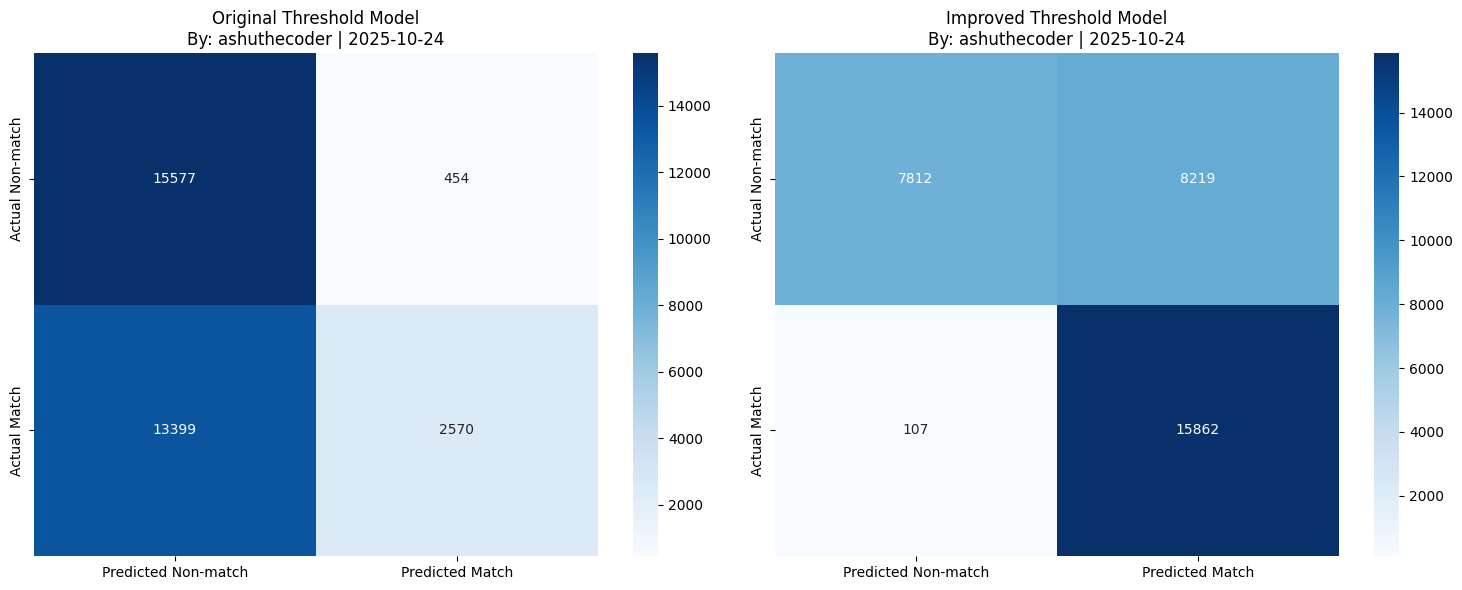

In [11]:
# Visualize threshold model performance
print("\n" + "="*80)
print("THRESHOLD MODELS - CONFUSION MATRICES")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm_original = confusion_matrix(train_data_clean['label'].astype(int),
                             train_data_clean['original_pred'])
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-match', 'Predicted Match'],
            yticklabels=['Actual Non-match', 'Actual Match'], ax=axes[0])
axes[0].set_title('Original Threshold Model\nBy: ashuthecoder | 2025-10-24')

cm_improved = confusion_matrix(train_data_clean['label'].astype(int),
                             train_data_clean['improved_pred'])
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-match', 'Predicted Match'],
            yticklabels=['Actual Non-match', 'Actual Match'], ax=axes[1])
axes[1].set_title('Improved Threshold Model\nBy: ashuthecoder | 2025-10-24')

plt.tight_layout()
plt.show()

In [12]:
# Prepare features for ML model
print("\n" + "="*80)
print("FEATURE PREPARATION FOR MACHINE LEARNING")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

def prepare_features(df):
    """Prepare features with Content-Based Filtering"""
    features = pd.DataFrame()
    features['tfidf_cosine'] = df['tfidf_cosine']
    features['hashed_jaccard'] = df['hashed_jaccard']
    features['length_diff_pct'] = df['length_diff_pct']

    # Content-Based Filtering features
    features['cbf_diagnoses_sim'] = df['cbf_diagnoses_sim']
    features['cbf_symptoms_sim'] = df['cbf_symptoms_sim']
    features['cbf_procedures_sim'] = df['cbf_procedures_sim']
    features['cbf_medications_sim'] = df['cbf_medications_sim']
    features['cbf_body_parts_sim'] = df['cbf_body_parts_sim']
    features['cbf_overall_similarity'] = df['cbf_overall_similarity']

    # Handle age difference
    age_diff = df['age_diff'].copy()
    median_age_diff = age_diff.median()
    features['age_diff'] = age_diff.fillna(median_age_diff)

    # One-hot encode gender_match
    features['gender_match_same'] = (df['gender_match'] == 1).astype(int)
    features['gender_match_diff'] = (df['gender_match'] == 0).astype(int)
    features['gender_match_unknown'] = (df['gender_match'] == -1).astype(int)

    return features

print("Preparing features...")
X = prepare_features(train_data)
y = train_data['label']

print(f"✓ Features prepared")
print(f"  Feature shape: {X.shape}")
print(f"  Total features: {len(X.columns)}")
print(f"\nFeature list:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


FEATURE PREPARATION FOR MACHINE LEARNING
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Preparing features...
✓ Features prepared
  Feature shape: (32000, 13)
  Total features: 13

Feature list:
   1. tfidf_cosine
   2. hashed_jaccard
   3. length_diff_pct
   4. cbf_diagnoses_sim
   5. cbf_symptoms_sim
   6. cbf_procedures_sim
   7. cbf_medications_sim
   8. cbf_body_parts_sim
   9. cbf_overall_similarity
  10. age_diff
  11. gender_match_same
  12. gender_match_diff
  13. gender_match_unknown


In [13]:
# Train Random Forest model
print("\n" + "="*80)
print("RANDOM FOREST MODEL TRAINING")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

# Split data
print("Splitting data (70% train, 30% test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"  Train size: {len(X_train)}")
print(f"  Test size: {len(X_test)}")

# Train Random Forest model
print("\nTraining Random Forest (n_estimators=100, class_weight='balanced')...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

print("\n" + "="*50)
print("Random Forest Model Performance - TRAIN SET")
print("="*50)
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")

print("\n" + "="*50)
print("Random Forest Model Performance - TEST SET")
print("="*50)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n✓ Top 10 Feature Importance:")
print("="*50)
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['Feature']:30s}: {row['Importance']:.4f}")


RANDOM FOREST MODEL TRAINING
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Splitting data (70% train, 30% test)...
  Train size: 22400
  Test size: 9600

Training Random Forest (n_estimators=100, class_weight='balanced')...

Random Forest Model Performance - TRAIN SET
Accuracy: 1.0000

Random Forest Model Performance - TEST SET
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4786
           1       0.98      0.97      0.98      4814

    accuracy                           0.98      9600
   macro avg       0.98      0.98      0.98      9600
weighted avg       0.98      0.98      0.98      9600

Accuracy: 0.9786

✓ Top 10 Feature Importance:
  hashed_jaccard                : 0.4198
  tfidf_cosine                  : 0.3103
  cbf_body_parts_sim            : 0.0964
  cbf_overall_similarity        : 0.0711
  cbf_procedures_sim            : 0.0306
  cbf_diagnoses_sim             : 0.0230
  length_diff_pct               : 0.0181



FEATURE IMPORTANCE VISUALIZATION


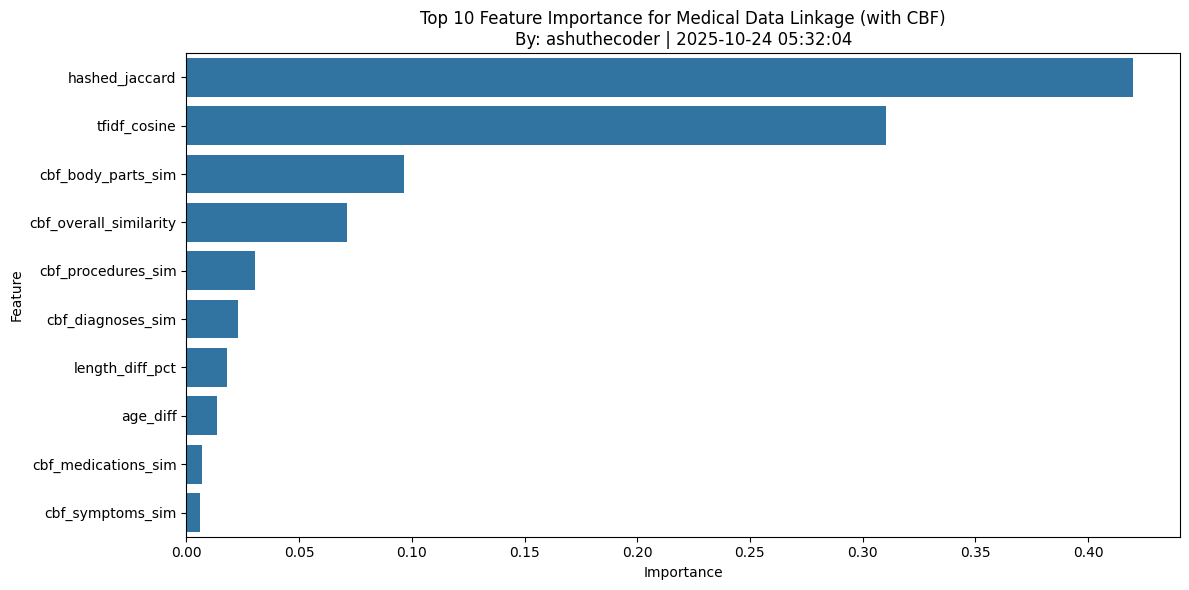

In [14]:
# Visualize feature importance
print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATION")
print("="*80)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importance for Medical Data Linkage (with CBF)\nBy: ashuthecoder | 2025-10-24 05:32:04')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [15]:
# Differential Privacy implementation
print("\n" + "="*80)
print("DIFFERENTIAL PRIVACY - SINGLE EPSILON")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

def add_laplace_noise(data, epsilon=1.0):
    """Add Laplace noise for differential privacy"""
    sensitivity = 1.0
    scale = sensitivity / epsilon
    return data + np.random.laplace(0, scale, size=len(data))

def apply_differential_privacy(df, epsilon=1):
    """Apply differential privacy to numeric features"""
    df_private = df.copy()
    for col in df.select_dtypes(include=[np.number]).columns:
        if not df[col].isnull().any():
            df_private[col] = add_laplace_noise(df[col].values, epsilon)
    return df_private

# Apply differential privacy
print("Applying differential privacy (epsilon=2.0)...")
X_private = apply_differential_privacy(X, epsilon=2)

# Compare original and privacy-protected features
print("\n✓ Comparison of Original vs. Privacy-Protected Features:")
print("="*80)
for col in ['tfidf_cosine', 'cbf_overall_similarity', 'hashed_jaccard']:
    print(f"\n{col}:")
    print(f"  Original - Mean: {X[col].mean():7.4f}, Std: {X[col].std():7.4f}")
    print(f"  Private  - Mean: {X_private[col].mean():7.4f}, Std: {X_private[col].std():7.4f}")
print("="*80)


DIFFERENTIAL PRIVACY - SINGLE EPSILON
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Applying differential privacy (epsilon=2.0)...

✓ Comparison of Original vs. Privacy-Protected Features:

tfidf_cosine:
  Original - Mean:  0.2941, Std:  0.2247
  Private  - Mean:  0.2938, Std:  0.7385

cbf_overall_similarity:
  Original - Mean:  0.1851, Std:  0.1659
  Private  - Mean:  0.1827, Std:  0.7286

hashed_jaccard:
  Original - Mean:  0.0542, Std:  0.0735
  Private  - Mean:  0.0540, Std:  0.7058


In [16]:
# Differential Privacy with multiple epsilon values
print("\n" + "="*80)
print("PRIVACY-UTILITY TRADEOFF ANALYSIS")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

def add_laplace_noise_sensitive(data, epsilon, sensitivity=1.0):
    """Add Laplace noise with configurable sensitivity"""
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale, size=data.shape)
    return data + noise

def apply_differential_privacy_advanced(df, epsilon=1.0, columns=None):
    """Apply DP to selected columns"""
    df_private = df.copy()
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    column_epsilon = epsilon / len(columns)

    for col in columns:
        if col in df.columns:
            col_range = df[col].max() - df[col].min()
            sensitivity = col_range * 0.01
            df_private[col] = add_laplace_noise_sensitive(df[col].values, column_epsilon, sensitivity)

    return df_private

# Test with multiple epsilon values
print("Testing multiple epsilon values...")
print("Lower epsilon = More privacy, Less accuracy")
print("Higher epsilon = Less privacy, More accuracy")
print()

epsilons = [10.0, 1.0, 0.8, 0.6, 0.4, 0.2, 0.1]
private_accuracies = {}
numeric_features = ['tfidf_cosine', 'hashed_jaccard', 'age_diff', 'length_diff_pct']

for epsilon in epsilons:
    print(f"Testing epsilon = {epsilon:5.1f}...", end=" ")

    # Apply DP
    X_private = apply_differential_privacy_advanced(X, epsilon=epsilon, columns=numeric_features)

    # Split
    X_train_private, X_test_private, y_train_split, y_test_split = train_test_split(
        X_private, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train
    rf_private = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_private.fit(X_train_private, y_train_split)

    # Evaluate
    y_pred_private = rf_private.predict(X_test_private)
    accuracy = accuracy_score(y_test_split, y_pred_private)
    private_accuracies[epsilon] = accuracy
    print(f"Accuracy: {accuracy:.4f}")

print("\n✓ Privacy-utility tradeoff analysis complete")


PRIVACY-UTILITY TRADEOFF ANALYSIS
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Testing multiple epsilon values...
Lower epsilon = More privacy, Less accuracy
Higher epsilon = Less privacy, More accuracy

Testing epsilon =  10.0... Accuracy: 0.9768
Testing epsilon =   1.0... Accuracy: 0.9443
Testing epsilon =   0.8... Accuracy: 0.9416
Testing epsilon =   0.6... Accuracy: 0.9311
Testing epsilon =   0.4... Accuracy: 0.9176
Testing epsilon =   0.2... Accuracy: 0.8940
Testing epsilon =   0.1... Accuracy: 0.8783

✓ Privacy-utility tradeoff analysis complete



PRIVACY-UTILITY TRADEOFF VISUALIZATION


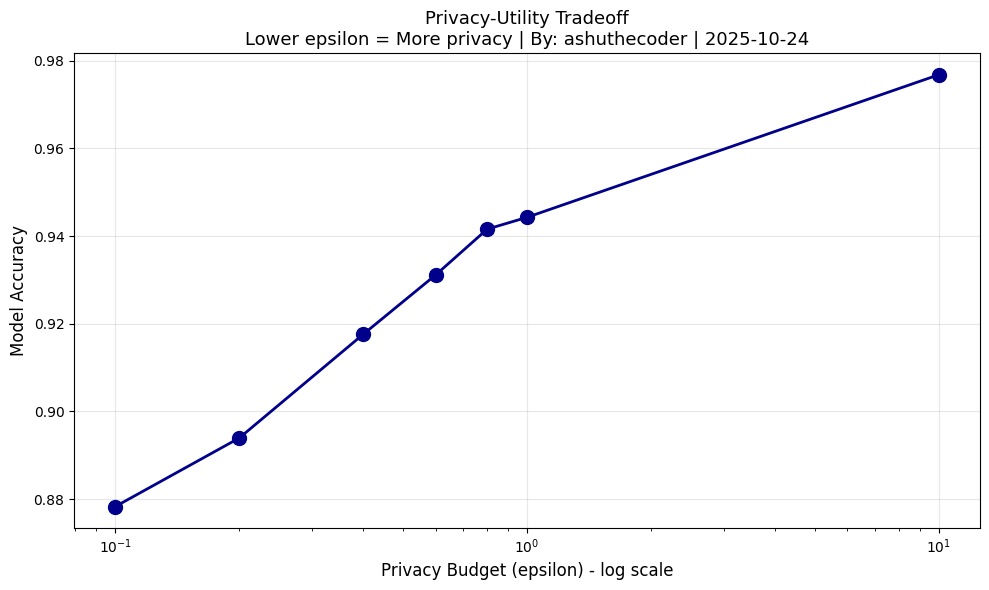


Privacy-Utility Tradeoff Table:
Epsilon         Accuracy        Privacy Level
10.0            0.9768          Low
1.0             0.9443          Low
0.8             0.9416          Medium
0.6             0.9311          Medium
0.4             0.9176          High
0.2             0.8940          High
0.1             0.8783          High


In [17]:
# Visualize privacy-utility tradeoff
print("\n" + "="*80)
print("PRIVACY-UTILITY TRADEOFF VISUALIZATION")
print("="*80)

plt.figure(figsize=(10, 6))
eps_values = list(private_accuracies.keys())
acc_values = list(private_accuracies.values())

plt.plot(eps_values, acc_values, 'o-', linewidth=2, markersize=10, color='darkblue')
plt.xscale('log')
plt.xlabel('Privacy Budget (epsilon) - log scale', fontsize=12)
plt.ylabel('Model Accuracy', fontsize=12)
plt.title('Privacy-Utility Tradeoff\nLower epsilon = More privacy | By: ashuthecoder | 2025-10-24', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/privacy_utility_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPrivacy-Utility Tradeoff Table:")
print("="*50)
print(f"{'Epsilon':<15} {'Accuracy':<15} {'Privacy Level'}")
print("="*50)
for eps, acc in sorted(private_accuracies.items(), reverse=True):
    privacy_level = "Low" if eps >= 1.0 else "Medium" if eps >= 0.5 else "High"
    print(f"{eps:<15.1f} {acc:<15.4f} {privacy_level}")
print("="*50)

In [18]:
# Process test data function
print("\n" + "="*80)
print("TEST DATA PROCESSING FUNCTION")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

def process_new_data(new_data, vectorizer, rf_model):
    """
    Process new data for prediction with CBF
    Created by: ashuthecoder | Date: 2025-10-24 05:32:04
    """
    # Preprocess text
    new_data['processed_text1'] = new_data['text1'].apply(lambda x: preprocess_text_robust(x))
    new_data['processed_text2'] = new_data['text2'].apply(lambda x: preprocess_text_robust(x))

    # Hashed n-grams
    new_data['hashed_ngrams1'] = new_data['processed_text1'].apply(create_hashed_ngrams)
    new_data['hashed_ngrams2'] = new_data['processed_text2'].apply(create_hashed_ngrams)
    new_data['hashed_jaccard'] = new_data.apply(
        lambda row: jaccard_similarity_hashed(row['hashed_ngrams1'], row['hashed_ngrams2']),
        axis=1
    )

    # Extract medical information
    new_data['medical_info1'] = new_data['text1'].apply(extract_medical_information)
    new_data['medical_info2'] = new_data['text2'].apply(extract_medical_information)

    # Demographics
    new_data['age1'] = new_data['medical_info1'].apply(lambda x: x.get('age'))
    new_data['gender1'] = new_data['medical_info1'].apply(lambda x: x.get('gender'))
    new_data['age2'] = new_data['medical_info2'].apply(lambda x: x.get('age'))
    new_data['gender2'] = new_data['medical_info2'].apply(lambda x: x.get('gender'))

    # Medical features for CBF
    new_data['diagnoses1'] = new_data['medical_info1'].apply(lambda x: x.get('diagnoses', []))
    new_data['diagnoses2'] = new_data['medical_info2'].apply(lambda x: x.get('diagnoses', []))
    new_data['symptoms1'] = new_data['medical_info1'].apply(lambda x: x.get('symptoms', []))
    new_data['symptoms2'] = new_data['medical_info2'].apply(lambda x: x.get('symptoms', []))
    new_data['procedures1'] = new_data['medical_info1'].apply(lambda x: x.get('procedures', []))
    new_data['procedures2'] = new_data['medical_info2'].apply(lambda x: x.get('procedures', []))
    new_data['medications1'] = new_data['medical_info1'].apply(lambda x: x.get('medications', []))
    new_data['medications2'] = new_data['medical_info2'].apply(lambda x: x.get('medications', []))
    new_data['body_parts1'] = new_data['medical_info1'].apply(lambda x: x.get('body_parts', []))
    new_data['body_parts2'] = new_data['medical_info2'].apply(lambda x: x.get('body_parts', []))

    # CBF similarities
    new_data['cbf_diagnoses_sim'] = new_data.apply(
        lambda row: calculate_medical_feature_similarity(row['diagnoses1'], row['diagnoses2']), axis=1
    )
    new_data['cbf_symptoms_sim'] = new_data.apply(
        lambda row: calculate_medical_feature_similarity(row['symptoms1'], row['symptoms2']), axis=1
    )
    new_data['cbf_procedures_sim'] = new_data.apply(
        lambda row: calculate_medical_feature_similarity(row['procedures1'], row['procedures2']), axis=1
    )
    new_data['cbf_medications_sim'] = new_data.apply(
        lambda row: calculate_medical_feature_similarity(row['medications1'], row['medications2']), axis=1
    )
    new_data['cbf_body_parts_sim'] = new_data.apply(
        lambda row: calculate_medical_feature_similarity(row['body_parts1'], row['body_parts2']), axis=1
    )
    new_data['cbf_overall_similarity'] = (
        0.3 * new_data['cbf_diagnoses_sim'] +
        0.2 * new_data['cbf_symptoms_sim'] +
        0.2 * new_data['cbf_procedures_sim'] +
        0.15 * new_data['cbf_medications_sim'] +
        0.15 * new_data['cbf_body_parts_sim']
    )

    # TF-IDF
    tfidf1 = vectorizer.transform(new_data['processed_text1'])
    tfidf2 = vectorizer.transform(new_data['processed_text2'])
    cosine_similarities = []
    for i in range(len(new_data)):
        similarity = cosine_similarity(tfidf1[i:i+1], tfidf2[i:i+1])[0][0]
        cosine_similarities.append(similarity)
    new_data['tfidf_cosine'] = cosine_similarities

    # Other features
    new_data['age_diff'] = new_data.apply(
        lambda row: abs(row['age1'] - row['age2']) if (pd.notna(row['age1']) and pd.notna(row['age2'])) else None,
        axis=1
    )
    new_data['gender_match'] = new_data.apply(
        lambda row: 1 if row['gender1'] == row['gender2'] and pd.notna(row['gender1']) else
                   0 if (pd.notna(row['gender1']) and pd.notna(row['gender2'])) else -1,
        axis=1
    )
    new_data['length_diff_pct'] = new_data.apply(
        lambda row: abs(len(row['text1']) - len(row['text2'])) / max(len(row['text1']), len(row['text2'])),
        axis=1
    )

    # Prepare features and predict
    X_new = prepare_features(new_data)
    predictions = rf_model.predict(X_new)
    probabilities = rf_model.predict_proba(X_new)[:, 1]

    new_data['predicted_match'] = predictions
    new_data['match_probability'] = probabilities

    return new_data

print("✓ Test data processing function defined")


TEST DATA PROCESSING FUNCTION
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

✓ Test data processing function defined


In [19]:
# Load and process test data
print("\n" + "="*80)
print("PROCESSING TEST DATA")
print("="*80)
print("Created by: ashuthecoder | Date: 2025-10-24 05:32:04")
print()

try:
    print("Loading test data from /content/target_test.csv...")
    test_data = pd.read_csv('/content/target_test.csv', header=0)

    # Remove header rows if they exist
    test_data = test_data[test_data['uid1'] != 'uid1'].reset_index(drop=True)

    if test_data.shape[1] == 1:
        col_name = test_data.columns[0]
        parts = test_data[col_name].str.split(',', expand=True)
        test_data = pd.DataFrame({
            'uid1': parts[0],
            'text1': parts[1],
            'uid2': parts[2],
            'text2': parts[3],
            'label': parts[4]
        })

    print(f"✓ Test data loaded: {test_data.shape}")

    # Process test data
    print("\nProcessing test data (this may take a moment)...")
    result_data = process_new_data(test_data, vectorizer, rf_model)

    # Display results
    print("\n✓ Test Data Predictions (First 10 records):")
    print("="*80)
    display_cols = ['uid1', 'uid2', 'predicted_match', 'match_probability']
    print(result_data[display_cols].head(10).to_string(index=False))

    # Evaluate if labels available
    if 'label' in result_data.columns:
        result_data['label'] = pd.to_numeric(result_data['label'], errors='coerce')
        result_data_eval = result_data.dropna(subset=['label'])

        print("\n" + "="*80)
        print("MODEL PERFORMANCE ON TEST DATA")
        print("="*80)
        print(classification_report(result_data_eval['label'], result_data_eval['predicted_match']))
        print(f"\nOverall Accuracy: {accuracy_score(result_data_eval['label'], result_data_eval['predicted_match']):.4f}")

except Exception as e:
    print(f"❌ Error processing test data: {e}")
    print("Skipping test data evaluation.")


PROCESSING TEST DATA
Created by: ashuthecoder | Date: 2025-10-24 05:32:04

Loading test data from /content/target_test.csv...
✓ Test data loaded: (8000, 5)

Processing test data (this may take a moment)...

✓ Test Data Predictions (First 10 records):
     uid1      uid2  predicted_match  match_probability
6159344-1 8454461-1                0               0.00
4743268-1 4743268-2                1               1.00
8442437-3 8442437-4                1               1.00
8625395-1 8625395-4                1               0.79
2687548-2 2687548-9                1               1.00
5929396-1 7870684-1                0               0.16
8603360-3 8603360-4                1               1.00
7444960-1 8674538-1                0               0.00
5552653-3 5552653-6                1               1.00
4972887-1 6051101-1                0               0.03

MODEL PERFORMANCE ON TEST DATA
              precision    recall  f1-score   support

           0       0.98      0.98      0.98  


CONFUSION MATRIX - TEST DATA
✓ Confusion matrix saved to: /content/confusion_matrix.png


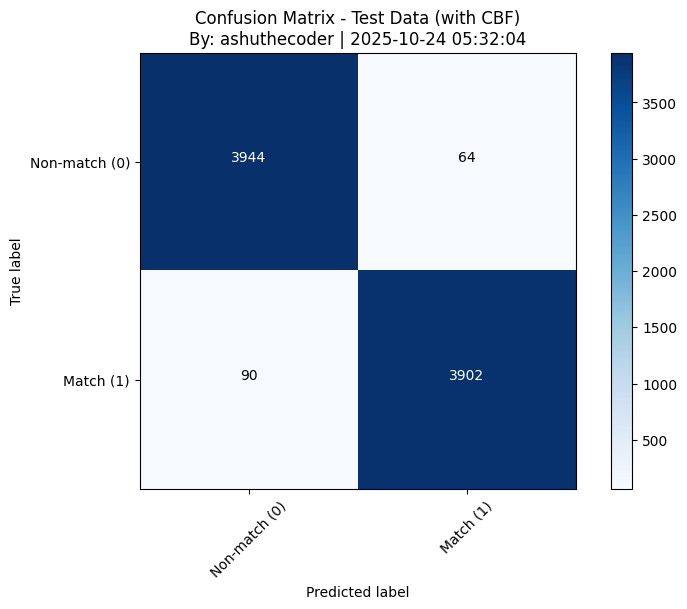

In [20]:
# Confusion matrix for test data
print("\n" + "="*80)
print("CONFUSION MATRIX - TEST DATA")
print("="*80)

import itertools

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
    else:
        fmt = 'd'

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

if 'label' in result_data.columns and 'result_data_eval' in locals():
    cm = confusion_matrix(result_data_eval['label'].astype(int), result_data_eval['predicted_match'])
    plot_confusion_matrix(cm, classes=['Non-match (0)', 'Match (1)'],
                         title='Confusion Matrix - Test Data (with CBF)\nBy: ashuthecoder | 2025-10-24 05:32:04')
    plt.savefig('/content/confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("✓ Confusion matrix saved to: /content/confusion_matrix.png")
    plt.show()


ROC CURVE - TEST DATA
✓ ROC curve saved to: /content/roc_curve.png


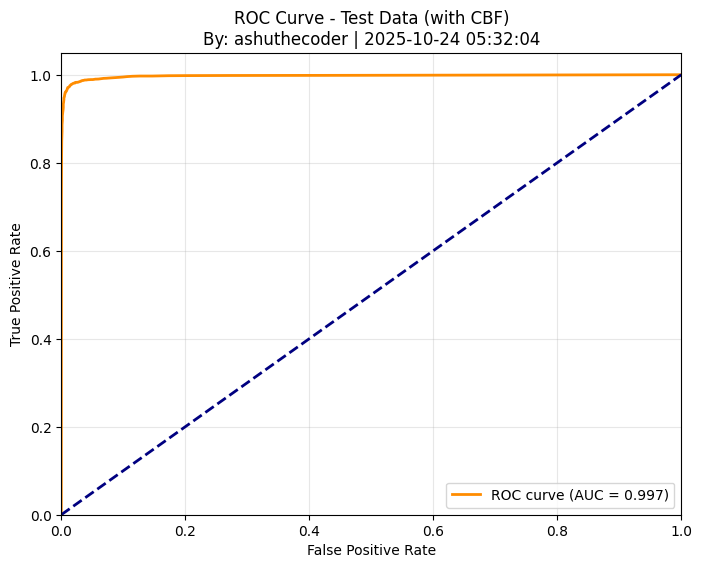

In [21]:
# ROC curve for test data
print("\n" + "="*80)
print("ROC CURVE - TEST DATA")
print("="*80)

if 'label' in result_data.columns and 'result_data_eval' in locals():
    fpr, tpr, _ = roc_curve(result_data_eval['label'], result_data_eval['match_probability'])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Test Data (with CBF)\nBy: ashuthecoder | 2025-10-24 05:32:04')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('/content/roc_curve.png', dpi=300, bbox_inches='tight')
    print("✓ ROC curve saved to: /content/roc_curve.png")
    plt.show()

In [22]:
# Save model and components
print("\n" + "="*80)
print("SAVING MODEL AND COMPONENTS")
print("="*80)

model_artifacts = {
    'model': rf_model,
    'vectorizer': vectorizer,
    'feature_names': X.columns.tolist(),
    'metadata': {
        'created_date': '2025-10-24 05:32:04',
        'created_date_utc': '2025-10-24 05:32:04',
        'created_by': 'ashuthecoder',
        'version': '2.0_CBF',
        'accuracy_train': accuracy_score(y_train, rf_model.predict(X_train)),
        'accuracy_test': accuracy_score(y_test, y_pred),
        'privacy_methods': [
            'text_anonymization',
            'hashed_ngrams',
            'tfidf_vectors',
            'differential_privacy'
        ],
        'feature_extraction': 'comprehensive_medical_info_with_cbf',
        'cbf_features': [
            'diagnoses',
            'symptoms',
            'procedures',
            'medications',
            'body_parts',
            'test_results'
        ],
        'total_features': len(X.columns),
        'cbf_weights': {
            'diagnoses': 0.30,
            'symptoms': 0.20,
            'procedures': 0.20,
            'medications': 0.15,
            'body_parts': 0.15
        },
        'dataset': {
            'train_size': len(train_data),
            'test_size': len(X_test),
            'train_test_split': 0.3
        }
    }
}

with open('/content/medical_linkage_model_cbf.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("✓ Model saved as 'medical_linkage_model_cbf.pkl'")
print(f"\nModel Metadata:")
print(f"{'─'*80}")
print(f"  Created by:        {model_artifacts['metadata']['created_by']}")
print(f"  Created date:      {model_artifacts['metadata']['created_date_utc']}")
print(f"  Version:           {model_artifacts['metadata']['version']}")
print(f"  Train accuracy:    {model_artifacts['metadata']['accuracy_train']:.4f}")
print(f"  Test accuracy:     {model_artifacts['metadata']['accuracy_test']:.4f}")
print(f"  Total features:    {model_artifacts['metadata']['total_features']}")
print(f"{'─'*80}")


SAVING MODEL AND COMPONENTS
✓ Model saved as 'medical_linkage_model_cbf.pkl'

Model Metadata:
────────────────────────────────────────────────────────────────────────────────
  Created by:        ashuthecoder
  Created date:      2025-10-24 05:32:04
  Version:           2.0_CBF
  Train accuracy:    1.0000
  Test accuracy:     0.9786
  Total features:    13
────────────────────────────────────────────────────────────────────────────────


In [ ]:
# Final summary
print("\n" + "="*80)
print("IMPLEMENTATION SUMMARY")
print("="*80)

print(f"""
✅ Privacy-Preserving Medical Record Linkage with Content-Based Filtering

IMPLEMENTATION DETAILS:
─────────────────────────────────────────────────────────────────────────────
Created by:    ashuthecoder
Date:          2025-10-24 05:32:04
Version:       2.0_CBF (Content-Based Filtering)
Dataset:       {len(train_data)} training records

KEY IMPROVEMENTS:
─────────────────
""")

SyntaxError: incomplete input (ipython-input-2226360983.py, line 6)

In [ ]:
# =================================================================================================
# Post-processing and Reporting Block (Run this as ONE cell at the very end in Google Colab)
# Adds comprehensive evaluation, plots, and tables for your CBF implementation.
# Assumes the following variables already exist from your previous cells:
#   - train_data, X, y, rf_model, X_train, X_test, y_train, y_test, y_pred
#   - result_data and result_data_eval (optional; created if you processed test_data)
#
# This block will:
#   1) Compute probabilities
#   2) Build extraction coverage table + bar chart
#   3) Produce test metrics table (Accuracy, Precision, Recall, F1, ROC-AUC)
#   4) Plot Precision–Recall curve
#   5) Perform threshold sweep (Precision/Recall/F1/Accuracy vs threshold) and plot
#   6) Plot calibration (reliability) curve + Brier score
#   7) Compute permutation importance (model-agnostic) and plot
#   8) Run ablation study (baseline vs baseline+CBF)
#   9) Error analysis: show top false positives/negatives (if labels available in result_data)
#
# All figures are saved to /content/*.png and tables to /content/*.csv for easy download.
# =================================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

# ---------------------------------------------------------------------------------
# 0) Safety checks for required variables from previous cells
# ---------------------------------------------------------------------------------
required_vars = ['train_data', 'X', 'y', 'rf_model', 'X_test', 'y_test']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects from earlier cells: {missing}. "
                       "Run the training/evaluation cells before this one.")

# Ensure y_pred exists (it was printed earlier, but recompute if needed)
if 'y_pred' not in globals():
    y_pred = rf_model.predict(X_test)

# ---------------------------------------------------------------------------------
# 1) Probabilities for PR, Calibration, Threshold tuning
# ---------------------------------------------------------------------------------
print("\n[1/9] Computing predicted probabilities for the test set...")
y_proba = rf_model.predict_proba(X_test)[:, 1]
print("✓ Probabilities computed.")

# ---------------------------------------------------------------------------------
# 2) Extraction coverage table + bar chart (TRAIN set; repeat for TEST if desired)
# ---------------------------------------------------------------------------------
print("\n[2/9] Building extraction coverage table + bar chart...")
coverage = pd.DataFrame({
    'feature': ['age', 'gender', 'diagnoses', 'symptoms', 'procedures', 'medications', 'test_results', 'body_parts'],
    'coverage_pct': [
        train_data['age1'].notna().mean()*100,
        train_data['gender1'].notna().mean()*100,
        (train_data['diagnoses1'].apply(len) > 0).mean()*100,
        (train_data['symptoms1'].apply(len) > 0).mean()*100,
        (train_data['procedures1'].apply(len) > 0).mean()*100,
        (train_data['medications1'].apply(len) > 0).mean()*100,
        (train_data['test_results1'].apply(len) > 0).mean()*100,
        (train_data['body_parts1'].apply(len) > 0).mean()*100,
    ]
}).sort_values('coverage_pct', ascending=False)

print("\nExtraction Coverage (% of records with at least one value) [TRAIN]:")
print(coverage.to_string(index=False, formatters={'coverage_pct': '{:.1f}'.format}))
coverage.to_csv('/content/extraction_coverage_train.csv', index=False)

plt.figure(figsize=(8,5))
sns.barplot(x='coverage_pct', y='feature', data=coverage, palette='Blues_r')
plt.xlabel('Coverage (%)')
plt.ylabel('Feature')
plt.title('Extraction Coverage by Category (TRAIN)\nBy: ashuthecoder')
plt.tight_layout()
plt.savefig('/content/extraction_coverage.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: /content/extraction_coverage.png and /content/extraction_coverage_train.csv")

# ---------------------------------------------------------------------------------
# 3) Test-set metrics table
# ---------------------------------------------------------------------------------
print("\n[3/9] Computing test-set metrics table...")
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

metrics_tbl = pd.DataFrame([{
    'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc
}])

print("\nTest-set Metrics:")
print(metrics_tbl.round(4).to_string(index=False))
metrics_tbl.to_csv('/content/test_metrics.csv', index=False)
print("✓ Saved: /content/test_metrics.csv")

# ---------------------------------------------------------------------------------
# 4) Precision–Recall curve
# ---------------------------------------------------------------------------------
print("\n[4/9] Plotting Precision–Recall curve...")
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve - Test Data (with CBF)\nBy: ashuthecoder')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: /content/pr_curve.png")

# ---------------------------------------------------------------------------------
# 5) Threshold sweep (choose operating point by F1) + plot
# ---------------------------------------------------------------------------------
print("\n[5/9] Running threshold sweep for decision threshold selection...")
def threshold_sweep(y_true, y_score, steps=101):
    rows = []
    for t in np.linspace(0, 1, steps):
        y_hat = (y_score >= t).astype(int)
        rows.append({
            'threshold': t,
            'precision': precision_score(y_true, y_hat, zero_division=0),
            'recall': recall_score(y_true, y_hat, zero_division=0),
            'f1': f1_score(y_true, y_hat, zero_division=0),
            'accuracy': accuracy_score(y_true, y_hat)
        })
    df = pd.DataFrame(rows)
    best = df.sort_values('f1', ascending=False).iloc[0]
    return df, best

sweep_df, best_row = threshold_sweep(y_test, y_proba)
print("\nBest threshold by F1 (Test Set):")
print(best_row.to_frame().T.round(4).to_string(index=False))
sweep_df.to_csv('/content/threshold_sweep.csv', index=False)

plt.figure(figsize=(9,6))
plt.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision')
plt.plot(sweep_df['threshold'], sweep_df['recall'], label='Recall')
plt.plot(sweep_df['threshold'], sweep_df['f1'], label='F1', linewidth=2)
plt.plot(sweep_df['threshold'], sweep_df['accuracy'], label='Accuracy', linestyle='--')
plt.axvline(best_row['threshold'], color='k', linestyle=':', label=f"Best F1 @ {best_row['threshold']:.2f}")
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Sweep (Precision/Recall/F1/Accuracy)\nBy: ashuthecoder')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/threshold_sweep.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: /content/threshold_sweep.png and /content/threshold_sweep.csv")

# ---------------------------------------------------------------------------------
# 6) Calibration plot (reliability curve) + Brier score
# ---------------------------------------------------------------------------------
print("\n[6/9] Plotting calibration curve and computing Brier score...")
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')
brier = brier_score_loss(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],'--', color='gray', label='Perfectly calibrated')
plt.plot(prob_pred, prob_true, marker='o', label=f'RF (Brier={brier:.3f})')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Plot (Reliability Curve)\nBy: ashuthecoder')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: /content/calibration_curve.png (Brier score = {brier:.4f})")

# ---------------------------------------------------------------------------------
# 7) Permutation importance (model-agnostic)
# ---------------------------------------------------------------------------------
print("\n[7/9] Computing permutation importance (this may take ~30–90s)...")
perm = permutation_importance(rf_model, X_test, y_test, n_repeats=5, random_state=42, scoring='f1')
perm_imp = pd.DataFrame({'Feature': X_test.columns, 'Importance': perm.importances_mean}) \
            .sort_values('Importance', ascending=False)
print("\nPermutation Importance (Top 15):")
print(perm_imp.head(15).round(5).to_string(index=False))
perm_imp.to_csv('/content/permutation_importance.csv', index=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=perm_imp.head(15), palette='viridis')
plt.title('Permutation Importance (Top 15)\nBy: ashuthecoder')
plt.tight_layout()
plt.savefig('/content/permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: /content/permutation_importance.png and /content/permutation_importance.csv")

# ---------------------------------------------------------------------------------
# 8) Ablation study: Baseline vs Baseline+CBF
# ---------------------------------------------------------------------------------
print("\n[8/9] Running ablation study (Baseline vs Baseline+CBF)...")
baseline_cols = [
    'tfidf_cosine', 'hashed_jaccard', 'length_diff_pct',
    'age_diff', 'gender_match_same', 'gender_match_diff', 'gender_match_unknown'
]
missing_baseline = [c for c in baseline_cols if c not in X.columns]
if missing_baseline:
    raise RuntimeError(f"Missing baseline feature columns in X: {missing_baseline}")

cbf_cols = [c for c in X.columns if c not in baseline_cols]

def eval_model(X_tr, X_te, y_tr, y_te):
    m = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    m.fit(X_tr, y_tr)
    yp = m.predict(X_te)
    ys = m.predict_proba(X_te)[:,1]
    return {
        'Accuracy': accuracy_score(y_te, yp),
        'F1': precision_recall_fscore_support(y_te, yp, average='binary', zero_division=0)[2],
        'ROC-AUC': roc_auc_score(y_te, ys)
    }

# Split once (stratified) for fair comparison
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(X[baseline_cols], y, test_size=0.3, random_state=42, stratify=y)
Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(X,               y, test_size=0.3, random_state=42, stratify=y)

res_baseline = eval_model(Xtr_b, Xte_b, ytr_b, yte_b)
res_full     = eval_model(Xtr_f, Xte_f, ytr_f, yte_f)

ablation_tbl = pd.DataFrame([
    {'Setting': 'Baseline (no CBF)', **{k: round(v,4) for k,v in res_baseline.items()}},
    {'Setting': 'Baseline + CBF',   **{k: round(v,4) for k,v in res_full.items()}}
])

print("\nAblation Study Results:")
print(ablation_tbl.to_string(index=False))
ablation_tbl.to_csv('/content/ablation_results.csv', index=False)
print("✓ Saved: /content/ablation_results.csv")

# ---------------------------------------------------------------------------------
# 9) Error analysis: top False Positives / False Negatives (if labels available)
# ---------------------------------------------------------------------------------
print("\n[9/9] Error analysis on processed test data (if labels available)...")
if 'result_data_eval' in globals():
    df_err = result_data_eval.copy()
    df_err['is_fp'] = (df_err['label']==0) & (df_err['predicted_match']==1)
    df_err['is_fn'] = (df_err['label']==1) & (df_err['predicted_match']==0)

    top_fp = df_err[df_err['is_fp']].sort_values('match_probability', ascending=False) \
        [['uid1','uid2','match_probability','cbf_overall_similarity','tfidf_cosine']].head(5)
    top_fn = df_err[df_err['is_fn']].sort_values('match_probability', ascending=True) \
        [['uid1','uid2','match_probability','cbf_overall_similarity','tfidf_cosine']].head(5)

    print("\nTop 5 False Positives (highest predicted probability):")
    print(top_fp.to_string(index=False))
    print("\nTop 5 False Negatives (lowest predicted probability):")
    print(top_fn.to_string(index=False))

    top_fp.to_csv('/content/top_false_positives.csv', index=False)
    top_fn.to_csv('/content/top_false_negatives.csv', index=False)
    print("✓ Saved: /content/top_false_positives.csv and /content/top_false_negatives.csv")
else:
    print("result_data_eval not found. Skipping error analysis. "
          "If needed, run your test processing cell to create result_data and result_data_eval.")

print("\nAll reporting complete. Artifacts saved to /content/. You can download them from the Colab file browser.")
# =================================================================================================